In [89]:
import pandas as pd
import matplotlib.pyplot as plt
import altair as alt
#from config_ import nameC_bulk,nameC_cellulose,named13C_bulk, named13C_cellulose, named15N

In [90]:
named13C_cellulose = "δ13C (‰ v.s.V-PDB)"
named13C_bulk = "bulk_δ13C (‰ v.s.V-PDB)"
name18O = "δ18O in ‰ vs DeltaSMOW"
named15N = "δ15N (‰ v.s. V-PDB)"
nameC_bulk ="[C_b]%"
nameC_cellulose = "[C]%"
thick = "mean_thickness_(mm)"
though = "mean_toughness_(kN/m)"
LA = "Leaf area (cm²)"
name = "genus" + "especie"
TreeID_2025 = "TreeID_2025"
old_ID = "treeID_old"

# Guacamayos 2006 
Resultados del 2025 cuando Jurgen me envio las muestras.

In [91]:
## Cellulose results. 

NAPO= pd.read_excel(r"C:\Users\selene.baez\Downloads\NAPO_preliminar\Results_isofys\specs - AndreaChavez-2025.07.xlsx")
listado = pd.read_excel("Gua_oyc_listado.xlsx")

NAPO_2006 = NAPO[NAPO["Meas batch"].str.contains("NAPO2006", na=False)]

#NAPO_add = NAPO[NAPO["Sample ID"].isin(["p07-183"])] #HELP Check p09-0122, p09-0140
patrones = ["p06","p6","p7","p07","p08","p8","p27","p55"]#guacamayos 2006 enviados por Jurgen

filtrado_GUA = NAPO_2006[NAPO_2006["Sample ID"].str.contains("|".join(patrones), na=False)]
NAPO_add = NAPO[NAPO["Sample ID"].isin(["p07-183"])] #HELP Check p09-0122, p09-0140. COntroles

filtrado_GUA = pd.concat([filtrado_GUA, NAPO_add])
filtrado_GUA[["Plot","old treeID"]] =filtrado_GUA["Sample ID"].str.split("-",expand=True) 
filtrado_GUA["Type"] = "leaf pulverized"
filtrado_GUA = filtrado_GUA.drop(columns=["Meas batch","Comment"])
filtrado_GUA = filtrado_GUA.rename(columns={"δ13C":named13C_cellulose,"[C] in %":nameC_cellulose})


## Nutrientes Guacamayos 2006

In [92]:
#bulk HELP: añadir los años 
SEQ1= pd.read_excel(r"C:\Users\selene.baez\Downloads\NAPO_preliminar\Results_isofys\Andrea_bulk CN_2025.xlsx",sheet_name="SEQ1")
SEQ1 = SEQ1.iloc[7:] #deletes first 7 rows #SEQ1. Aca hay de Guacamayos
SEQ2 = pd.read_excel(r"C:\Users\selene.baez\Downloads\NAPO_preliminar\Results_isofys\Andrea_bulk CN_2025.xlsx",sheet_name="SEQ2")
SEQ2 = SEQ2.iloc[56:73+1] # aca hay p6,p7,p8 al final
#SEQ4 = pd.read_excel("Andrea_bulk CN_2025.xlsx",sheet_name="SEQ4")
#SEQ4 = SEQ4.iloc[7:]
#SEQ4["year"] = 2025
#SEQ5 = pd.read_excel("Andrea_bulk CN_2025.xlsx",sheet_name="SEQ5")
#SEQ5 = SEQ5.iloc[7:]
SEQ7 = pd.read_excel(r"C:\Users\selene.baez\Downloads\NAPO_preliminar\Results_isofys\Andrea_bulk CN_2025.xlsx",sheet_name="SEQ7")
SEQ7 = SEQ7.iloc[51:] # aca hay 23 y 29

bulk = pd.concat([SEQ1,SEQ2,SEQ7])
bulk = bulk.rename(columns={"certified values":"sample-ID", "Unnamed: 2":"[N]",
                            "Unnamed: 4":nameC_bulk,"Unnamed: 6":named15N,
                            "Unnamed: 8":named13C_bulk})
bulk = bulk.iloc[1:]#delete first row

bulk[["Plot","old treeID","a"]] =bulk["sample-ID"].str.split("-",expand=True)
columns_drop = ["Unnamed: 0", "Unnamed: 3","Unnamed: 5","Unnamed: 7", "Unnamed: 9","Unnamed: 10","Unnamed: 11","Unnamed: 12","a"]

patrones = ["p06","p6","p7","p07","p08","p8","p27","p55"]#guacamayos 2006 enviados por Jurgen

bulk = bulk[bulk["Plot"].str.contains("|".join(patrones), na=False)]

bulk = bulk.drop(columns=columns_drop)


In [93]:
### cellulose and bulk 2006

merged = pd.merge(filtrado_GUA,bulk, left_on="old treeID", right_on="old treeID", how="outer")
merged["Plot"] = merged["Plot_x"].combine_first(merged["Plot_y"])
drop = ["Sample ID","Plot_y","Plot_x"]
merged = merged.drop(columns = drop)
#merged["Site"] = "Guacamayos" #todos son Guacamayos 2006

cellulose_bulk_2006 = merged
cellulose_bulk_2006 = cellulose_bulk_2006.rename(columns={"[C] in %":nameC_cellulose,"δ13C":named13C_cellulose,"old treeID":"treeID_old"})

In [94]:
### Rasgos funcionales 2006

info = pd.read_excel("samples2006_Guacamayos&Galeras.xlsx") #rasgos 2006
info_gua = info[info["site"]=="Guacamayos"]
info_gua = info_gua[["site","plot","#","family","species (det 2008!)"]] #Cuando necesite añado los otros. Por ahora no

cellulose_bulk_2006["treeID_old"] = cellulose_bulk_2006["treeID_old"].astype("Float64")
GUA_2006 = pd.merge(cellulose_bulk_2006,info_gua, left_on = "treeID_old",right_on="#", how="outer") # El plot 27 Nan
GUA_2006["treeID_old"] = GUA_2006["treeID_old"].combine_first(GUA_2006["#"]) #limpiamos para unificar
GUA_2006 = GUA_2006.drop(columns=["site","Plot","#"])
GUA_2006["Year"] = 2006
GUA_2006["Site"] = "Guacamayos"

### quiero añadir informacion de las nuevas TreeID para relacionar con los arboles 
TreesID = pd.read_excel("02. Rasgos Guacamayos.xlsx")
TreesID = TreesID[["Plot","altitud","TreeID_2025","oldTreeID"]] #mantenemos el original porque le necesito abajo.
#TreesID = TreesID[["Plot","altitud","Date ","TreeID_2025","oldTreeID","SLA (cm2/g)","mean_thickness_(mm)"]]

GUA_2006_info = pd.merge(TreesID,GUA_2006, right_on= "treeID_old", left_on= "oldTreeID", how="right" )
GUA_2006_info["treeID_old"] = GUA_2006_info["treeID_old"].combine_first(GUA_2006_info["oldTreeID"]) #limpiamos para unificar
GUA_2006_info = GUA_2006_info.drop(columns=["oldTreeID","Plot"])# innecesaria #quedan varios espacios vacios especialmente por los rasgos de 2025.
GUA_2006_info = GUA_2006_info.rename(columns={"treeID_old":"treeID_old","TreeID_2025":"treeID_new","δ13C (‰ v.s.V-PDB)":named13C_cellulose,"plot":"Plot"})

GUA_2006_info["treeID_old"]= GUA_2006_info["treeID_old"].astype("Int64")
GUA_2006_info["Plot"] = (
    GUA_2006_info["Plot"]
    .astype("Int64")
    .astype(str)
    .str.zfill(2)
)
GUA_2006_info["Sample-ID"]= "p"+ GUA_2006_info["Plot"].astype(str)+"-"+GUA_2006_info["treeID_old"].astype(str)


## First year: Oyacachi + few herbarium from Guacamayos

In [95]:
#cellulose
results_ISMR = pd.read_excel(r"C:\Users\selene.baez\Downloads\NAPO_preliminar\Results_isofys\Resultis_ISMR_10072024.xlsx", sheet_name = "seq 1") #only seq1 has Napo results
subset = results_ISMR[["sample-ID","[C] m/m (%)","δ13C (‰ v.s. V-PDB)"]]
subset = subset.rename(columns = {"[C] m/m (%)":nameC_cellulose,"δ13C (‰ v.s. V-PDB)":named13C_cellulose})

## bulk
bulk = pd.read_excel(r"C:\Users\selene.baez\Downloads\NAPO_preliminar\Results_isofys\data overview.xlsx")
add = bulk[bulk["Sample"].isin([8023,56079,8194,8200])]
napo_bulk = bulk[bulk["Meas batch"] == "CN_S1"]
drop_columns = ["Unnamed: 2","Unnamed: 4","Unnamed: 6","Unnamed: 8","Meas batch"] #Aca hay unas desviaciones estandar. 0.118854 por ejemplo
napo_bulk = napo_bulk.drop(columns= drop_columns)

### bulk complete
mix_oyc_gua = pd.concat([napo_bulk,add])
mix_oyc_gua = mix_oyc_gua.rename(columns = {"[C] m/m":nameC_bulk,"δ13C (‰ v.s. V-PDB)":named13C_bulk,"[N] m/m":"[N]","δ15N (‰ v.s. V-PDB)":named15N})
mix_oyc_gua = mix_oyc_gua.drop(columns = drop_columns)
mix_oyc_gua

,Sample,[N],δ15N (‰ v.s. V-PDB),[C_b]%,bulk_δ13C (‰ v.s.V-PDB)
0,1689,3.357924,1.907002,41.921147,-27.333327
1,1711,1.996007,0.756532,42.594045,-31.069542
2,1715,2.765898,2.185417,44.371695,-31.492877
3,1738,2.053133,2.249046,46.564344,-31.687973
4,3150,3.044708,3.191434,38.714349,-30.713244
...,...,...,...,...,...
91,56128,2.557618,-1.288416,45.3998,-27.648438
64,8194,2.014609,0.49784,44.657171,-30.453959
65,8200,3.279822,1.691458,44.152205,-29.231435
339,8023,2.301508,43.157492,-1.422247,-30.800863


In [96]:
### muestras 2011 pulverizadas que son solo de OYC. 
# OK 

listado_2011 = listado[listado["leaf_sample_ID_2011"].notna()]
listado_2011[["leaf_sample_ID_2011","treeID_old","treeID_new","Site","family","species","herbarium specimen"]]

cell_2011 = pd.merge(listado_2011,subset,left_on="leaf_sample_ID_2011",right_on="sample-ID",how="left")
cell_2011 = cell_2011.drop(columns=["collection year","ID_Andrea"]) #ese TreeID es sampleID

cel_bulk_2011 = pd.merge(cell_2011,mix_oyc_gua,left_on="leaf_sample_ID_2011",right_on="Sample",how="left")
cel_bulk_2011 = cel_bulk_2011.drop(columns=["herbaria","sample-ID","Sample","pulverized"])
#cel_bulk_2011 = cel_bulk_2011.rename(columns=["herbaria","sample-ID","Sample","pulverized"])

cel_bulk_2011["Year"] = 2011
cel_bulk_2011["Type"] = "leaf pulverized"

cel_bulk_2011["treeID_old"]= cel_bulk_2011["treeID_old"].astype("Int64")
cel_bulk_2011["Plot"] = (
    cel_bulk_2011["Plot"]
    .astype("Int64")
    .astype(str)
    .str.zfill(2)
)
cel_bulk_2011["Sample-ID"]= "p"+ cel_bulk_2011["Plot"].astype(str)+"-"+cel_bulk_2011["treeID_old"].astype(str)

In [97]:
### muestras del herbario
## OK
listado_hb = listado[listado["herbarium specimen"].notna()]
listado_hb[["herbarium specimen","treeID_old","treeID_new","Site","family","species"]]

cell_hb = pd.merge(listado_hb,subset,left_on="herbarium specimen",right_on="sample-ID",how="left")
cell_hb = cell_hb.drop(columns=["ID_Andrea","leaf_sample_ID_2011","pulverized","herbaria"]) #ese TreeID es sampleID
cell_hb = cell_hb.dropna() #son solo 7
cell_hb = cell_hb.rename(columns={"collection year":"Year","[N] m/m}":"[N]"}) #homogeneize columns
cell_hb["Type"] = "herbarium"

cel_bulk_hb = pd.merge(cell_hb,mix_oyc_gua,left_on="herbarium specimen",right_on="Sample",how="left")
cel_bulk_hb = cel_bulk_hb.drop(columns=["sample-ID","Sample"])
cel_bulk_hb["Sample-ID"] = "p"+ cel_bulk_hb["Plot"].astype("Int64").astype(str).str.zfill(2) +"-"+ cel_bulk_hb["herbarium specimen"].astype(str)

## Muestras pulverizadas 2023
Esos codigos deben ser asignados TreeIDs

In [98]:
#homogeneizar los nombres
def homogeneizar(df,columna_nombre):
 df[columna_nombre] = df[columna_nombre].replace({4101:8076,
                             4101:8067,
                             4105:8071,
                             4244:8068,
                             4027:8052,
                             4020:8016,
                             4100:8066,
                             "4838.1":4838,#eliminar
                            "4838.2":4838,
                             161:8194,
                             169:8200,
                             4021:8013,
                             4100:8066,
                             186:8151,
                             151:8182,
                             4022:8039,
                             4043:8080,
                             4106:8076
                    })
 return df

In [99]:
#remove from samples 
lista = cel_bulk_hb["herbarium specimen"].tolist() + \
        cel_bulk_2011["leaf_sample_ID_2011"].tolist()

cel_2025 = subset[~subset["sample-ID"].isin(lista)]
cel_2025 = homogeneizar(cel_2025,"sample-ID")

### datos de los tests
nuevos = pd.DataFrame({
    "sample-ID": [8154, 8182, 8151],
    nameC_cellulose: [46.84, 45.65, 46.30],
    named13C_cellulose: [-30.02, -30.25, -26.81]
})

cel_2025 = pd.concat([cel_2025, nuevos], ignore_index=True)

bulk_2025 = mix_oyc_gua[~mix_oyc_gua["Sample"].isin(lista)]
bulk_2025 = homogeneizar(bulk_2025,"Sample")

samples_2025 = pd.merge(cel_2025,bulk_2025,left_on="sample-ID",right_on="Sample",how="outer")
listado = listado[["Plot","treeID_new","treeID_old","family","species","Site"]]
cel_bulk_2025 = pd.merge(listado,samples_2025, left_on="treeID_new",right_on="Sample",how="outer") #Sample esta completo
cel_bulk_2025 = cel_bulk_2025.drop(columns={"Sample"})
cel_bulk_2025["Year"]=2023
cel_bulk_2025["Type"]="leaf pulverized"

cel_bulk_2025["treeID_new"]= cel_bulk_2025["treeID_new"].astype("Int64")
cel_bulk_2025["Plot"] = (
    cel_bulk_2025["Plot"]
    .astype("Int64")
    .astype(str)
    .str.zfill(2)
)
cel_bulk_2025["Sample-ID"]= "p"+ cel_bulk_2025["Plot"].astype(str)+"-"+cel_bulk_2025["treeID_new"].astype(str)
cel_bulk_2025

C:\Users\selene.baez\AppData\Local\Temp\ipykernel_8252\2577713693.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[columna_nombre] = df[columna_nombre].replace({4101:8076,
C:\Users\selene.baez\AppData\Local\Temp\ipykernel_8252\2577713693.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[columna_nombre] = df[columna_nombre].replace({4101:8076,
C:\Users\selene.baez\AppData\Local\Temp\ipykernel_8252\751636218.py:20: UserWarning: You are merging on int and float columns where the float values are not

,Plot,treeID_new,treeID_old,family,species,Site,sample-ID,[C]%,δ13C (‰ v.s.V-PDB),[N],δ15N (‰ v.s. V-PDB),[C_b]%,bulk_δ13C (‰ v.s.V-PDB),Year,Type,Sample-ID
0,06,8186,157.0,Euphorbiaceae,Sapium stylare,Guacamayos,8186.0,33.238998,-28.65,2.520188,0.684126,42.025991,-29.878491,2023,leaf pulverized,p06-8186
1,06,8194,161.0,Meliaceae,Guarea kunthiana,Guacamayos,8194.0,46.214582,-29.11,2.014609,0.49784,44.657171,-30.453959,2023,leaf pulverized,p06-8194
2,06,8194,161.0,Meliaceae,Guarea kunthiana,Guacamayos,8194.0,46.214582,-29.11,2.014609,0.49784,44.657171,-30.453959,2023,leaf pulverized,p06-8194
3,06,8188,158.0,Fabaceae,Dussia tessmanniii,Guacamayos,8188.0,44.273753,-29.41,3.195462,-0.099221,43.620485,-30.200606,2023,leaf pulverized,p06-8188
4,06,8182,151.0,Rubiaceae,Posoqueria,Guacamayos,8182.0,45.650000,-30.25,1.691991,0.559787,39.008307,-30.727078,2023,leaf pulverized,p06-8182
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60,55,8124,1647.0,Lauraceae,Nectandra laurel,Guacamayos,8124.0,45.041465,-28.82,1.702766,-2.280938,47.067798,-30.543458,2023,leaf pulverized,p55-8124
61,55,8106,1678.0,Rubiaceae,Farameo oblongifolia,Guacamayos,8106.0,43.463094,-28.07,2.067487,-0.230846,39.798852,-29.249163,2023,leaf pulverized,p55-8106
62,07,8154,NaN,Rubiaceae,Joosia ulei,Guacamayos,8154.0,46.840000,-30.02,2.450345,-0.148932,44.044598,-31.487876,2023,leaf pulverized,p07-8154
63,<NA>,<NA>,NaN,NaN,NaN,NaN,4038.1,59.861848,-29.97,NaN,NaN,NaN,NaN,2023,leaf pulverized,p<NA>-<NA>


Unir Miscelanea

In [100]:
mis2026 = pd.read_excel(r"C:\Users\selene.baez\Downloads\NAPO_preliminar\Results_isofys\Report 13C-pq4.xlsx")
mis2026["Sample ID"] =  mis2026["Sample ID"].astype(str).replace({"pxx-1711":"p06-1711","p8x-4142":"p85-4112"}) ### REVISAR HELP 1711
mis2026 = mis2026.rename(columns={"Sample ID":"Sample-ID"})#arriba todo con guion
mis2026 = mis2026.rename(columns={"[C] m/m":nameC_cellulose,"δ13C (‰ v.s. V-PDB)":named13C_cellulose})

patrones = ["06","07","08","27","55","12","81","82","85","83"]
regex = r"^p(" + "|".join(patrones) + r")-"
mis2026 = mis2026[mis2026["Sample-ID"].str.contains(regex, na=False)] #Filtremos solo SUMACO
mis2026= mis2026[["Sample-ID",nameC_cellulose,named13C_cellulose]]
#### separamos los de parcelas
mis2026= mis2026[mis2026["Sample-ID"] != "p06-8186"] #p06-8186 valor muy bajo de C, 8158 eliminar
mis2026= mis2026[mis2026["Sample-ID"] != "p07-8158"]
#mis2026.loc[mis2026["Sample-ID"] == "p10-241", ["old_treeID", "Year","Plot"]] = [8878, 2006,10]
mis2026[nameC_cellulose] = mis2026[nameC_cellulose]*100
## Falta unir la informacion de las familias y generos #merge


C:\Users\selene.baez\AppData\Local\Temp\ipykernel_8252\645090424.py:8: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mis2026 = mis2026[mis2026["Sample-ID"].str.contains(regex, na=False)] #Filtremos solo SUMACO


In [101]:
df1 = pd.concat([cel_bulk_2011,cel_bulk_2025,cel_bulk_hb]) #primero unificar este
all= pd.concat([df1,GUA_2006_info])
len(all)#152


152

In [102]:
# Unir por Sample ID con las nuevas de la miscelanea
df_actualizado = all.merge(
    mis2026,
    on='Sample-ID',
    how='left',
    suffixes=('', '_new')
)

In [103]:
# Reemplazar solo cuando exista un valor nuevo
df_actualizado[nameC_cellulose] = df_actualizado["[C]%_new"].combine_first(df_actualizado[nameC_cellulose])
df_actualizado[named13C_cellulose] = df_actualizado["δ13C (‰ v.s.V-PDB)_new"].combine_first(df_actualizado[named13C_cellulose])

#Create genus and species
df_actualizado["genus_species"] = df_actualizado["species"].combine_first(df_actualizado["species (det 2008!)"])#una sola
df_actualizado[["genus","species2","species3","species4","species5"]]= df_actualizado["genus_species"].str.split(" ",expand=True)
# Eliminar columnas temporales
df_actualizado = df_actualizado.drop(columns={"δ13C (‰ v.s.V-PDB)_new","altitud","species","species (det 2008!)"})
df = df_actualizado.rename(columns={"treeID_new":"new_TreeID","treeID_old":"old_treeID"})
df = df.drop(columns={"sample-ID"})
df = df[df["Plot"] != "<NA>"]
df["Plot"] = df["Plot"].astype(int)
df.to_excel("iWUE_OYC_GUA.xlsx")


In [104]:
import openpyxl

RUTA = "iWUE_OYC_GUA.xlsx"  # ajusta la ruta si es necesario

wb = openpyxl.load_workbook(RUTA)
ws = wb["Sheet1"]

# Mapear encabezados -> número de columna
headers = {cell.value: idx for idx, cell in enumerate(ws[1], start=1) if cell.value}

COL_NEW_TREEID   = headers["new_TreeID"]
COL_OLD_TREEID   = headers["old_treeID"]
COL_PLOT         = headers["Plot"]
COL_SITE         = headers["Site"]
COL_GENUS        = headers["genus"]
COL_SPECIES2     = headers["species2"]
COL_GENUS_SPECIES= headers["genus_species"]

# Si la columna "comment" no existe todavía, se crea al final
if "comment" not in headers:
    COL_COMMENT = ws.max_column + 1
    ws.cell(row=1, column=COL_COMMENT, value="comment")
else:
    COL_COMMENT = headers["comment"]

# Mapeo old_treeID -> new_TreeID a aplicar (solo dentro de Guacamayos, Plot 7)
NUEVOS_TREEID = {200: 8159, 190: 8152, 183: 8150}

SITE_OBJETIVO = "Guacamayos"
PLOT_OBJETIVO = 7

for row in range(2, ws.max_row + 1):
    site = ws.cell(row=row, column=COL_SITE).value
    plot = ws.cell(row=row, column=COL_PLOT).value
    old_id = ws.cell(row=row, column=COL_OLD_TREEID).value

    if site == SITE_OBJETIVO and plot == PLOT_OBJETIVO and old_id in NUEVOS_TREEID:
        nuevo_id = NUEVOS_TREEID[old_id]
        ws.cell(row=row, column=COL_NEW_TREEID, value=nuevo_id)
        print(f"Fila {row}: old_treeID={old_id} -> new_TreeID={nuevo_id}")

        # Corrección de especie y comentario solo para old_treeID = 200
        if old_id == 200:
            ws.cell(row=row, column=COL_GENUS, value="Aniba")
            ws.cell(row=row, column=COL_SPECIES2, value="muca")
            ws.cell(row=row, column=COL_GENUS_SPECIES, value="Aniba muca")
            ws.cell(
                row=row, column=COL_COMMENT,
                value="Especie corregida de 'Aniba cf coto' a Aniba muca tras revisión taxonómica"
            )

wb.save(RUTA)
print("Archivo guardado.")

Fila 78: old_treeID=183 -> new_TreeID=8150
Fila 103: old_treeID=200 -> new_TreeID=8159
Fila 117: old_treeID=190 -> new_TreeID=8152
Fila 137: old_treeID=183 -> new_TreeID=8150
Fila 138: old_treeID=183 -> new_TreeID=8150
Fila 139: old_treeID=183 -> new_TreeID=8150
Archivo guardado.


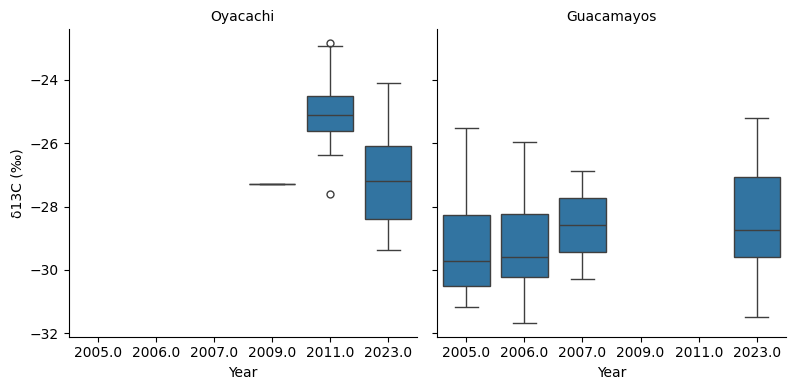

In [105]:
import seaborn as sns
import matplotlib.pyplot as plt


#df_actualizado["Plot"] = df_actualizado["Plot"].astype("Int64")

g = sns.catplot(
    data=df_actualizado,
    x="Year",
    y= "δ13C (‰ v.s.V-PDB)",   # o el nombre exacto de tu columna
    col="Site",     # facet por sitio
    kind="box",
    height=4,
    aspect=1
)

g.set_axis_labels("Year", "δ13C (‰)")
g.set_titles("{col_name}")  # título = nombre del sitio

plt.show()

In [106]:
import calculate_iWUE_oyc
%run calculate_iWUE_oyc

df = df_actualizado.apply(lambda row: calculate_iWUE(row, co2_dict), axis=1)

In [107]:
import elevation_dict
%run elevation_dict
df["Elevation"] = df.set_index(["Site", "Plot"]).index.map(elevation_dict)


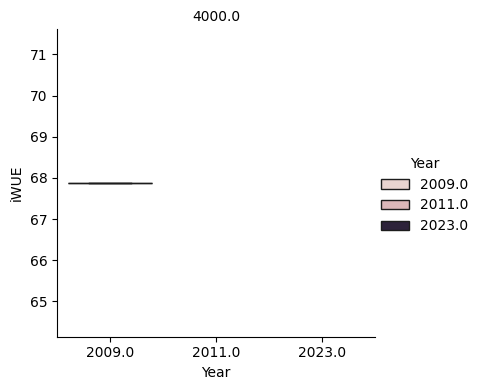

In [108]:
OYC  = df[df["Site"]=="Oyacachi"]

palette = {
    2009: "grey",
    2011: "blue",
    2023: "orange"
}

g = sns.catplot(
    data=OYC,
    x="Year",
    y= "iWUE (μmol/mol)",   # o el nombre exacto de tu columna
    col="Elevation",     # facet por sitio
    kind="box",
    hue="Year",
    height=4,
    aspect=1
    
)


g.set_axis_labels("Year", "iWUE")
g.set_titles("{col_name}")  # título = nombre del sitio

plt.show()

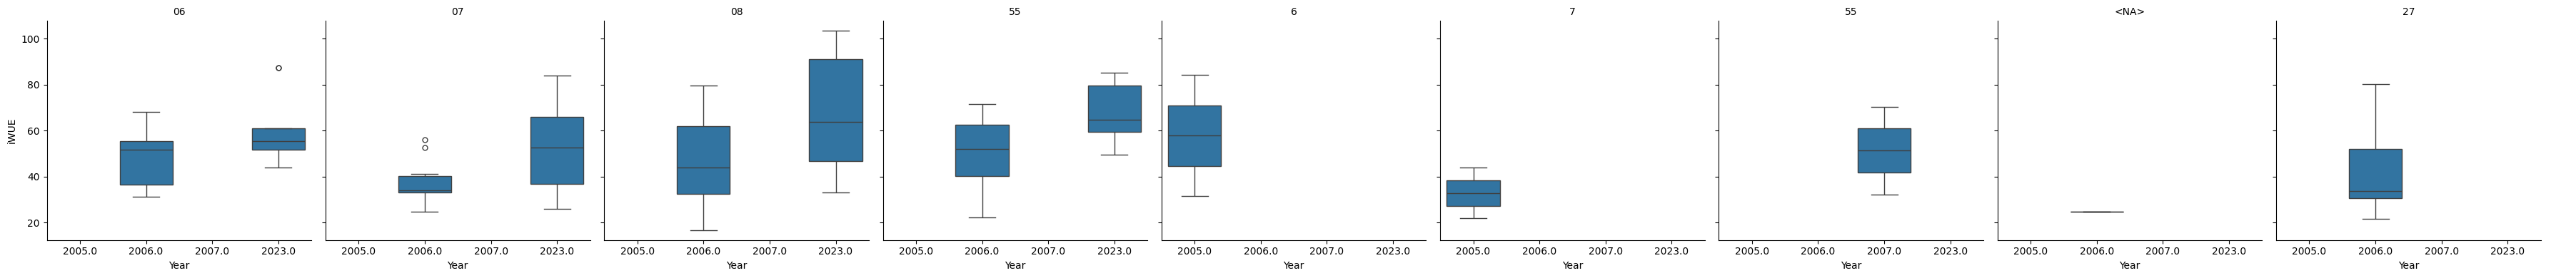

In [109]:
GUA  = df[df["Site"]=="Guacamayos"]

g = sns.catplot(
    data=GUA,
    x="Year",
    y= "iWUE (μmol/mol)",   # o el nombre exacto de tu columna
    col="Plot",     # facet por sitio
    kind="box",
    height=4,
    aspect=1
)

g.set_axis_labels("Year", "iWUE")
g.set_titles("{col_name}")  # título = nombre del sitio

plt.show()